In [3]:
# Dataset Columns: 
# UserID, ChargerID, ChargerCompany, Location, ChargerType,
# StartDay, StartTime, EndDay, EndTime, StartDatetime, 
# EndDatetime, Duration, Demand
"""                                                                                                                           
Nature EV Dataset Analysis                                                                                                    
Dataset: 72,856 sessions from 2,238 users and 2,119 chargers                                                                  
Source: Nature Scientific Data 2024                                                                                           
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
from pathlib import Path

In [20]:
class NatureEVAnalyzer:
    """Analyze Nature EV dataset with custom column structure"""
    
    def __init__(self, dataset_path='ChargingRecords.csv'):
        self.dataset_path = dataset_path
        self.setup_directories()
        
    def setup_directories(self):
        directories = [
            'data/users/raw/',
            'data/users/processed/',
            'data/integrated/'
        ]
        
        for directory in directories:
            Path(directory).mkdir(parents=True, exist_ok=True)
        
        print("Directories created")
    
    #load dataset                                                                                                             
    def load_dataset(self):
        print("\n LOADING NATURE EV DATASET...")
        print("=" * 70)
        
        try:
            df = pd.read_csv(self.dataset_path)
            
            print(f" Dataset loaded successfully!")
            print(f" Total records: {len(df):,}")
            print(f" Columns: {list(df.columns)}")
            
            # Basic info
            print(f"\n Dataset Overview:")
            print(f"   Unique Users: {df['UserID'].nunique():,}")
            print(f"   Unique Chargers: {df['ChargerID'].nunique():,}")
            
            # Check data types
            print(f"\n Column Data Types:")
            for col in df.columns:
                print(f"   {col:20s}: {df[col].dtype}")
            
            # Preview data
            print(f"\n First 3 Records:")
            print(df.head(3))
            
            # Missing values
            print(f"\n Missing Values Check:")
            missing = df.isnull().sum()
            if missing.sum() > 0:
                print(missing[missing > 0])
            else:
                print("   No missing values! ")
            
            self.raw_data = df
            return df
            
        except FileNotFoundError:
            print(f" Error: Could not find '{self.dataset_path}'")
            print(f" Current directory files:")
            import os
            print([f for f in os.listdir('.') if f.endswith('.csv')])
            return None
        except Exception as e:
            print(f" Error: {e}")
            return None

    #--DATA PROCESSING--                                                                                                      

    def preprocess_data(self,df):
        
        df = df.copy()
        df = df.copy()
        
        # Convert datetime columns
        print(" Converting datetime columns...")
        try:
            df['StartDatetime'] = pd.to_datetime(df['StartDatetime'])
            df['EndDatetime'] = pd.to_datetime(df['EndDatetime'])
            print("    StartDatetime")
            print("    EndDatetime")
        except Exception as e:
            print(f"    Datetime conversion error: {e}")
        
        # Extract temporal features
        print("\n🔨 Extracting temporal features...")
        df['arrival_hour'] = df['StartDatetime'].dt.hour
        df['departure_hour'] = df['EndDatetime'].dt.hour
        df['day_of_week'] = df['StartDatetime'].dt.day_name()
        df['month'] = df['StartDatetime'].dt.month
        df['is_weekend'] = df['StartDatetime'].dt.dayofweek >= 5
        df['date'] = df['StartDatetime'].dt.date
        print("    arrival_hour, departure_hour")
        print("    day_of_week, month, is_weekend")
        
        # Process Duration (might be in different formats)
        print("\n⏱️ Processing Duration...")
        if df['Duration'].dtype == 'object':
            # If duration is a string (e.g., "02:30:00" or "2h 30m")
            try:
                # Try parsing as timedelta
                df['duration_hours'] = pd.to_timedelta(df['Duration']).dt.total_seconds() / 3600
                print("    Duration parsed from string format")
            except:
                # If that fails, calculate from start/end times
                df['duration_hours'] = (df['EndDatetime'] - df['StartDatetime']).dt.total_seconds() / 3600
                print("    Duration calculated from start/end times")
        else:
            # Duration might already be numeric (in hours or minutes)
            df['duration_hours'] = df['Duration']
            # Check if it's in minutes (values > 100 likely indicate minutes)
            if df['duration_hours'].median() > 100:
                df['duration_hours'] = df['duration_hours'] / 60
                print("   Duration converted from minutes to hours")
            else:
                print("    Duration already in hours")
        
        # Process Demand (energy delivered in kWh)
        print("\n Processing Energy Demand...")
        df['energy_kwh'] = df['Demand']
        print(f"    Energy column created")
        print(f"    Energy range: {df['energy_kwh'].min():.2f} - {df['energy_kwh'].max():.2f} kWh")
        
        # Calculate charging power
        df['avg_charging_power_kw'] = df['energy_kwh'] / df['duration_hours']
        # Remove infinite values (division by zero)
        df['avg_charging_power_kw'] = df['avg_charging_power_kw'].replace([np.inf, -np.inf], np.nan)
        print(f"    Average charging power calculated")
        
        # Estimate idle time (V2G opportunity window)
        # Assume typical charging takes energy_kwh / 7.2kW (Level 2 charger)
        typical_charging_power = 7.2  # kW
        df['charging_time_hours'] = df['energy_kwh'] / typical_charging_power
        df['idle_time_hours'] = (df['duration_hours'] - df['charging_time_hours']).clip(lower=0)
        df['v2g_available'] = df['idle_time_hours'] > 2  # Available if idle > 2 hours
        print(f"    V2G availability calculated")
        
        print(f"\n Preprocessing complete!")
        print(f"   Final shape: {df.shape}")
        print(f"   Date range: {df['StartDatetime'].min().date()} to {df['StartDatetime'].max().date()}")
        
        self.processed_data = df
        return df

    # =================== ANALYSIS FUNCTIONS ===================
    """Analyze when users arrive to charge"""
    def analyze_arrival_patterns(self, df):
        print("\n ANALYZING ARRIVAL PATTERNS...")

        # Hourly distribution                                                                                  
        arrival_dist = df['arrival_hour'].value_counts().sort_index()

        print(" Arrival Distribution by Hour:")
        for hour in range(24):
            count = arrival_dist.get(hour, 0)
            if arrival_dist.max() > 0:
                bar = '█' * int(count / arrival_dist.max() * 50)
                pct = (count / len(df)) * 100
                print(f"   {hour:02d}:00 | {bar} {count:,} ({pct:.1f}%)")

        # Peak hours                                                                                           
        peak_threshold = arrival_dist.quantile(0.75)
        peak_hours = arrival_dist[arrival_dist > peak_threshold].index.tolist()

        print(f"\n KEY INSIGHTS:")
        print(f"   Peak arrival hours: {sorted(peak_hours)}")
        print(f"   Most common hour: {arrival_dist.idxmax()}:00 ({arrival_dist.max():,} sessions)")
        print(f"   → These are optimal V2G discharge windows!")

        # Weekend vs Weekday                                                                                   
        print(f"\n Weekend vs Weekday:")
        weekday = df[~df['is_weekend']]['arrival_hour'].value_counts().sort_index()
        weekend = df[df['is_weekend']]['arrival_hour'].value_counts().sort_index()
        print(f"   Weekday peak: {weekday.idxmax()}:00")
        print(f"   Weekend peak: {weekend.idxmax()}:00")
        return {
            'hourly_distribution': arrival_dist.to_dict(),
            'peak_hours': peak_hours,
            'most_common_hour': int(arrival_dist.idxmax()),
            'weekday_peak': int(weekday.idxmax()),
            'weekend_peak': int(weekend.idxmax())
        }

    """Analyze when users need their vehicles back"""
    def analyze_departure_patterns(self, df):
        print("\n ANALYZING DEPARTURE PATTERNS...")

        departure_dist = df['departure_hour'].value_counts().sort_index()

        print(" Departure Distribution by Hour:")
        for hour in range(24):
            count = departure_dist.get(hour, 0)
            if departure_dist.max() > 0:
                bar = '█' * int(count / departure_dist.max() * 50)
                pct = (count / len(df)) * 100
                print(f"   {hour:02d}:00 | {bar} {count:,} ({pct:.1f}%)")

        # Morning departures (critical!)                                                                       
        morning = departure_dist[(departure_dist.index >= 5) & (departure_dist.index <= 10)]

        print(f"\n CRITICAL MORNING DEPARTURES (Must ensure full charge):")
        for hour, count in morning.items():
            pct = (count / len(df)) * 100
            print(f"   {hour:02d}:00: {count:,} sessions ({pct:.1f}%)")

        print(f"\n V2G Constraint:")
        print(f"   → Must complete charging by 5:00 AM for {morning.sum():,} sessions")
        print(f"   → That's {(morning.sum()/len(df)*100):.1f}% of all sessions")

        return {
            'hourly_distribution': departure_dist.to_dict(),
            'morning_departure_hours': morning.index.tolist(),
            'morning_departure_count': int(morning.sum()),
            'morning_departure_pct': float((morning.sum() / len(df)) * 100)
        }
    
    """Analyze parking duration and V2G opportunities"""
    def analyze_duration_and_v2g(self, df):
        print("ANALYZING DURATION & V2G OPPORTUNITIES...")
        # Remove extreme outliers
        df_clean = df[df['duration_hours'] <= 48].copy()
        outliers = len(df) - len(df_clean)
        if outliers > 0:
            print(f" Removed {outliers} outliers (duration > 48h)")
        
        print(" Parking Duration Statistics:")
        print(f"   Mean: {df_clean['duration_hours'].mean():.2f} hours")
        print(f"   Median: {df_clean['duration_hours'].median():.2f} hours")
        print(f"   25th percentile: {df_clean['duration_hours'].quantile(0.25):.2f} hours")
        print(f"   75th percentile: {df_clean['duration_hours'].quantile(0.75):.2f} hours")
        
        # Duration categories
        short = (df_clean['duration_hours'] < 2).sum()
        medium = ((df_clean['duration_hours'] >= 2) & (df_clean['duration_hours'] < 8)).sum()
        long = (df_clean['duration_hours'] >= 8).sum()
        
        print(f"\n Session Categories:")
        print(f"   Short (< 2h): {short:,} ({short/len(df_clean)*100:.1f}%) - Quick charge")
        print(f"   Medium (2-8h): {medium:,} ({medium/len(df_clean)*100:.1f}%) - Work/shopping")
        print(f"   Long (> 8h): {long:,} ({long/len(df_clean)*100:.1f}%) - Overnight")
        
        # V2G opportunity analysis
        print(f"\n V2G OPPORTUNITY ANALYSIS:")
        print(f"   Average charging time: {df_clean['charging_time_hours'].mean():.2f} hours")
        print(f"   Average idle time: {df_clean['idle_time_hours'].mean():.2f} hours")
        print(f"   → Average V2G window: {df_clean['idle_time_hours'].mean():.2f} hours per session")
        
        v2g_count = df_clean['v2g_available'].sum()
        v2g_pct = (v2g_count / len(df_clean)) * 100
        
        print(f"\n V2G AVAILABILITY:")
        print(f"   Sessions with >2h idle time: {v2g_count:,} ({v2g_pct:.1f}%)")
        print(f"   → That's {v2g_count:,} opportunities for V2G discharge!")
        
        return {
            'mean_duration': float(df_clean['duration_hours'].mean()),
            'median_duration': float(df_clean['duration_hours'].median()),
            'mean_idle_time': float(df_clean['idle_time_hours'].mean()),
            'v2g_available_count': int(v2g_count),
            'v2g_availability_pct': float(v2g_pct),
            'long_sessions_pct': float(long/len(df_clean)*100)
        }
    
    """Analyze energy consumption"""
    def analyze_energy_patterns(self, df):
        print("\n ANALYZING ENERGY PATTERNS...")
        
        df_clean = df[df['energy_kwh'] > 0].copy()
        
        print(" Energy Statistics:")
        print(f"   Mean: {df_clean['energy_kwh'].mean():.2f} kWh")
        print(f"   Median: {df_clean['energy_kwh'].median():.2f} kWh")
        print(f"   Total energy: {df_clean['energy_kwh'].sum():,.2f} kWh")
        print(f"   Range: {df_clean['energy_kwh'].min():.2f} - {df_clean['energy_kwh'].max():.2f} kWh")
        
        # V2G energy potential
        avg_v2g_energy = df_clean['energy_kwh'].mean() * 0.5  # 50% of charged energy
        total_daily_v2g = avg_v2g_energy * len(df_clean) / 365
        
        print(f"\n V2G ENERGY POTENTIAL:")
        print(f"   Average per session: {avg_v2g_energy:.2f} kWh")
        print(f"   Estimated daily total: {total_daily_v2g:.2f} kWh")
        print(f"   → Significant grid support capacity!")
        
        return {
            'mean_energy': float(df_clean['energy_kwh'].mean()),
            'median_energy': float(df_clean['energy_kwh'].median()),
            'total_energy': float(df_clean['energy_kwh'].sum()),
            'v2g_energy_potential': float(avg_v2g_energy)
        }
    
    """Analyze charging patterns by location"""
    def analyze_location_patterns(self, df):
        print("\n ANALYZING LOCATION PATTERNS...")
        print("=" * 70)
        
        location_stats = df.groupby('Location').agg({
            'UserID': 'count',
            'duration_hours': 'mean',
            'energy_kwh': 'mean',
            'v2g_available': 'mean'
        }).rename(columns={'UserID': 'session_count'})
        
        location_stats = location_stats.sort_values('session_count', ascending=False)
        
        print(f" Top Locations by Session Count:")
        for i, (loc, row) in enumerate(location_stats.head(10).iterrows(), 1):
            print(f"   {i:2d}. {loc:30s}: {int(row['session_count']):,} sessions")
            print(f"       Avg duration: {row['duration_hours']:.1f}h | "
                  f"Avg energy: {row['energy_kwh']:.1f} kWh | "
                  f"V2G avail: {row['v2g_available']*100:.1f}%")
        
        return location_stats

    """Cluster users by behavior"""
    def cluster_users(self, df):
        print("\n CLUSTERING USERS BY BEHAVIOR...")
        
        user_stats = df.groupby('UserID').agg({
            'arrival_hour': 'mean',
            'departure_hour': 'mean',
            'duration_hours': 'mean',
            'energy_kwh': 'mean',
            'v2g_available': 'mean',
            'UserID': 'count'
        }).rename(columns={'UserID': 'session_count'})
        
        # Classify users
        def classify_user(avg_arrival):
            if 6 <= avg_arrival < 12:
                return 'morning_charger'
            elif 12 <= avg_arrival < 18:
                return 'afternoon_charger'
            elif 18 <= avg_arrival < 24:
                return 'evening_charger'
            else:
                return 'night_charger'
        
        user_stats['cluster'] = user_stats['arrival_hour'].apply(classify_user)
        
        print(f" User Clusters:")
        print(f"   Total users: {len(user_stats):,}")
        print(f"   Avg sessions/user: {user_stats['session_count'].mean():.1f}")
        print(f"\n Cluster Distribution:")
        
        for cluster in ['evening_charger', 'morning_charger', 'afternoon_charger', 'night_charger']:
            cluster_data = user_stats[user_stats['cluster'] == cluster]
            count = len(cluster_data)
            pct = (count / len(user_stats)) * 100
            print(f"\n   {cluster:20s}: {count:,} users ({pct:.1f}%)")
            print(f"      Avg arrival: {cluster_data['arrival_hour'].mean():.1f}:00")
            print(f"      Avg duration: {cluster_data['duration_hours'].mean():.1f}h")
            print(f"      V2G availability: {cluster_data['v2g_available'].mean()*100:.1f}%")
        
        # Save user profiles
        user_stats.to_csv('data/users/processed/user_profiles_nature.csv')
        print(f"\n User profiles saved!")
        
        return user_stats

    # =================== VISUALS ===================
    def create_visualizations(self, df):
        print("\n CREATING VISUALIZATIONS...")
        print("=" * 70)
        
        fig, axes = plt.subplots(3, 2, figsize=(18, 15))
        fig.suptitle('WHO: Nature EV Dataset - User Behavior Analysis\n' +
                     f'{len(df):,} Sessions | {df["UserID"].nunique():,} Users', 
                     fontsize=16, fontweight='bold')
        
        # Plot 1: Arrival distribution
        ax1 = axes[0, 0]
        arrival_counts = df['arrival_hour'].value_counts().sort_index()
        colors = ['red' if 17 <= h <= 21 else 'steelblue' for h in arrival_counts.index]
        ax1.bar(arrival_counts.index, arrival_counts.values, color=colors, alpha=0.7)
        ax1.set_title(f'Arrival Time Distribution ({len(df):,} sessions)', fontweight='bold')
        ax1.set_xlabel('Hour of Day')
        ax1.set_ylabel('Number of Sessions')
        ax1.grid(True, alpha=0.3)
        ax1.axvspan(16.5, 21.5, alpha=0.2, color='red', label='Peak V2G window')
        ax1.legend()
        
        # Plot 2: Departure distribution
        ax2 = axes[0, 1]
        departure_counts = df['departure_hour'].value_counts().sort_index()
        colors = ['orange' if 5 <= h <= 10 else 'steelblue' for h in departure_counts.index]
        ax2.bar(departure_counts.index, departure_counts.values, color=colors, alpha=0.7)
        ax2.set_title('Departure Time Distribution', fontweight='bold')
        ax2.set_xlabel('Hour of Day')
        ax2.set_ylabel('Number of Sessions')
        ax2.grid(True, alpha=0.3)
        ax2.axvspan(4.5, 10.5, alpha=0.2, color='orange', label='Morning constraint')
        ax2.legend()
        
        # Plot 3: Duration histogram
        ax3 = axes[1, 0]
        df_clean = df[df['duration_hours'] <= 24]
        ax3.hist(df_clean['duration_hours'], bins=50, alpha=0.7, color='purple', edgecolor='black')
        ax3.axvline(df_clean['duration_hours'].mean(), color='r', linestyle='--',
                   linewidth=2, label=f'Mean: {df_clean["duration_hours"].mean():.1f}h')
        ax3.set_title('Parking Duration Distribution', fontweight='bold')
        ax3.set_xlabel('Duration (hours)')
        ax3.set_ylabel('Frequency')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Energy distribution
        ax4 = axes[1, 1]
        df_energy = df[df['energy_kwh'] > 0]
        ax4.hist(df_energy['energy_kwh'], bins=50, alpha=0.7, color='green', edgecolor='black')
        ax4.axvline(df_energy['energy_kwh'].mean(), color='r', linestyle='--',
                   linewidth=2, label=f'Mean: {df_energy["energy_kwh"].mean():.1f} kWh')
        ax4.set_title('Energy Delivered Distribution', fontweight='bold')
        ax4.set_xlabel('Energy (kWh)')
        ax4.set_ylabel('Frequency')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # Plot 5: Day of week
        ax5 = axes[2, 0]
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        day_counts = df['day_of_week'].value_counts().reindex(day_order, fill_value=0)
        colors_day = ['red' if day not in ['Saturday', 'Sunday'] else 'green' for day in day_order]
        ax5.bar(range(len(day_counts)), day_counts.values, color=colors_day, alpha=0.7)
        ax5.set_title('Sessions by Day of Week', fontweight='bold')
        ax5.set_xlabel('Day')
        ax5.set_ylabel('Number of Sessions')
        ax5.set_xticks(range(len(day_order)))
        ax5.set_xticklabels(day_order, rotation=45)
        ax5.grid(True, alpha=0.3)
        
        # Plot 6: V2G availability by hour
        ax6 = axes[2, 1]
        v2g_by_hour = df.groupby('arrival_hour')['v2g_available'].mean() * 100
        ax6.bar(v2g_by_hour.index, v2g_by_hour.values, alpha=0.7, color='green')
        ax6.set_title('V2G Availability by Arrival Hour', fontweight='bold')
        ax6.set_xlabel('Arrival Hour')
        ax6.set_ylabel('V2G Availability (%)')
        ax6.grid(True, alpha=0.3)
        ax6.axhline(y=50, color='r', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.savefig('eda_nature_user_patterns.png', dpi=300, bbox_inches='tight')
        plt.show()
    
        print("Visualization saved: eda_nature_user_patterns.png")

    # =================== MAIN WORKFLOW ===================
    
    def run_complete_analysis(self):
        # Load
        df = self.load_dataset()
        if df is None:
            return None, None
        
        # Preprocess
        df = self.preprocess_data(df)
        
        # Analyze
        print("\n" + "="*70)
        print("RUNNING ANALYSES...")
        print("="*70)
        
        arrival = self.analyze_arrival_patterns(df)
        departure = self.analyze_departure_patterns(df)
        duration = self.analyze_duration_and_v2g(df)
        energy = self.analyze_energy_patterns(df)
        location = self.analyze_location_patterns(df)
        users = self.cluster_users(df)
        
        # Visualize
        self.create_visualizations(df)
        
        # Compile results
        analysis = {
            'dataset_info': {
                'total_sessions': len(df),
                'unique_users': int(df['UserID'].nunique()),
                'unique_chargers': int(df['ChargerID'].nunique()),
                'date_range': f"{df['StartDatetime'].min().date()} to {df['StartDatetime'].max().date()}"
            },
            'arrival_patterns': arrival,
            'departure_patterns': departure,
            'duration_v2g': duration,
            'energy_patterns': energy,
            'user_clusters': {
                'total_users': len(users),
                'avg_sessions_per_user': float(users['session_count'].mean()),
                'clusters': users['cluster'].value_counts().to_dict()
            }
        }
        
        # Save
        with open('data/users/processed/nature_dataset_analysis.json', 'w') as f:
            json.dump(analysis, f, indent=2, default=str)
        
        print("\n" + "="*70)
        print(" ANALYSIS COMPLETE!")
        print("="*70)
        print("\n KEY FINDINGS:")
        print(f"   Sessions: {analysis['dataset_info']['total_sessions']:,}")
        print(f"   Users: {analysis['dataset_info']['unique_users']:,}")
        print(f"   Peak arrival: {arrival['most_common_hour']}:00")
        print(f"   V2G available: {duration['v2g_availability_pct']:.1f}%")
        print(f"   Avg idle time: {duration['mean_idle_time']:.2f}h")
        
        print("\n Files Created:")
        print("   • eda_nature_user_patterns.png")
        print("   • data/users/processed/user_profiles_nature.csv")
        print("   • data/users/processed/nature_dataset_analysis.json")
        
        return analysis, df

Directories created

 LOADING NATURE EV DATASET...
 Dataset loaded successfully!
 Total records: 72,856
 Columns: ['UserID', 'ChargerID', 'ChargerCompany', 'Location', 'ChargerType', 'StartDay', 'StartTime', 'EndDay', 'EndTime', 'StartDatetime', 'EndDatetime', 'Duration', 'Demand']

 Dataset Overview:
   Unique Users: 2,337
   Unique Chargers: 2,119

 Column Data Types:
   UserID              : int64
   ChargerID           : int64
   ChargerCompany      : int64
   Location            : object
   ChargerType         : int64
   StartDay            : object
   StartTime           : object
   EndDay              : object
   EndTime             : object
   StartDatetime       : object
   EndDatetime         : object
   Duration            : int64
   Demand              : float64

👀 First 3 Records:
   UserID  ChargerID  ChargerCompany Location  ChargerType    StartDay  \
0       0          1               1    hotel            0  2022-09-15   
1       0          1               1    hotel  

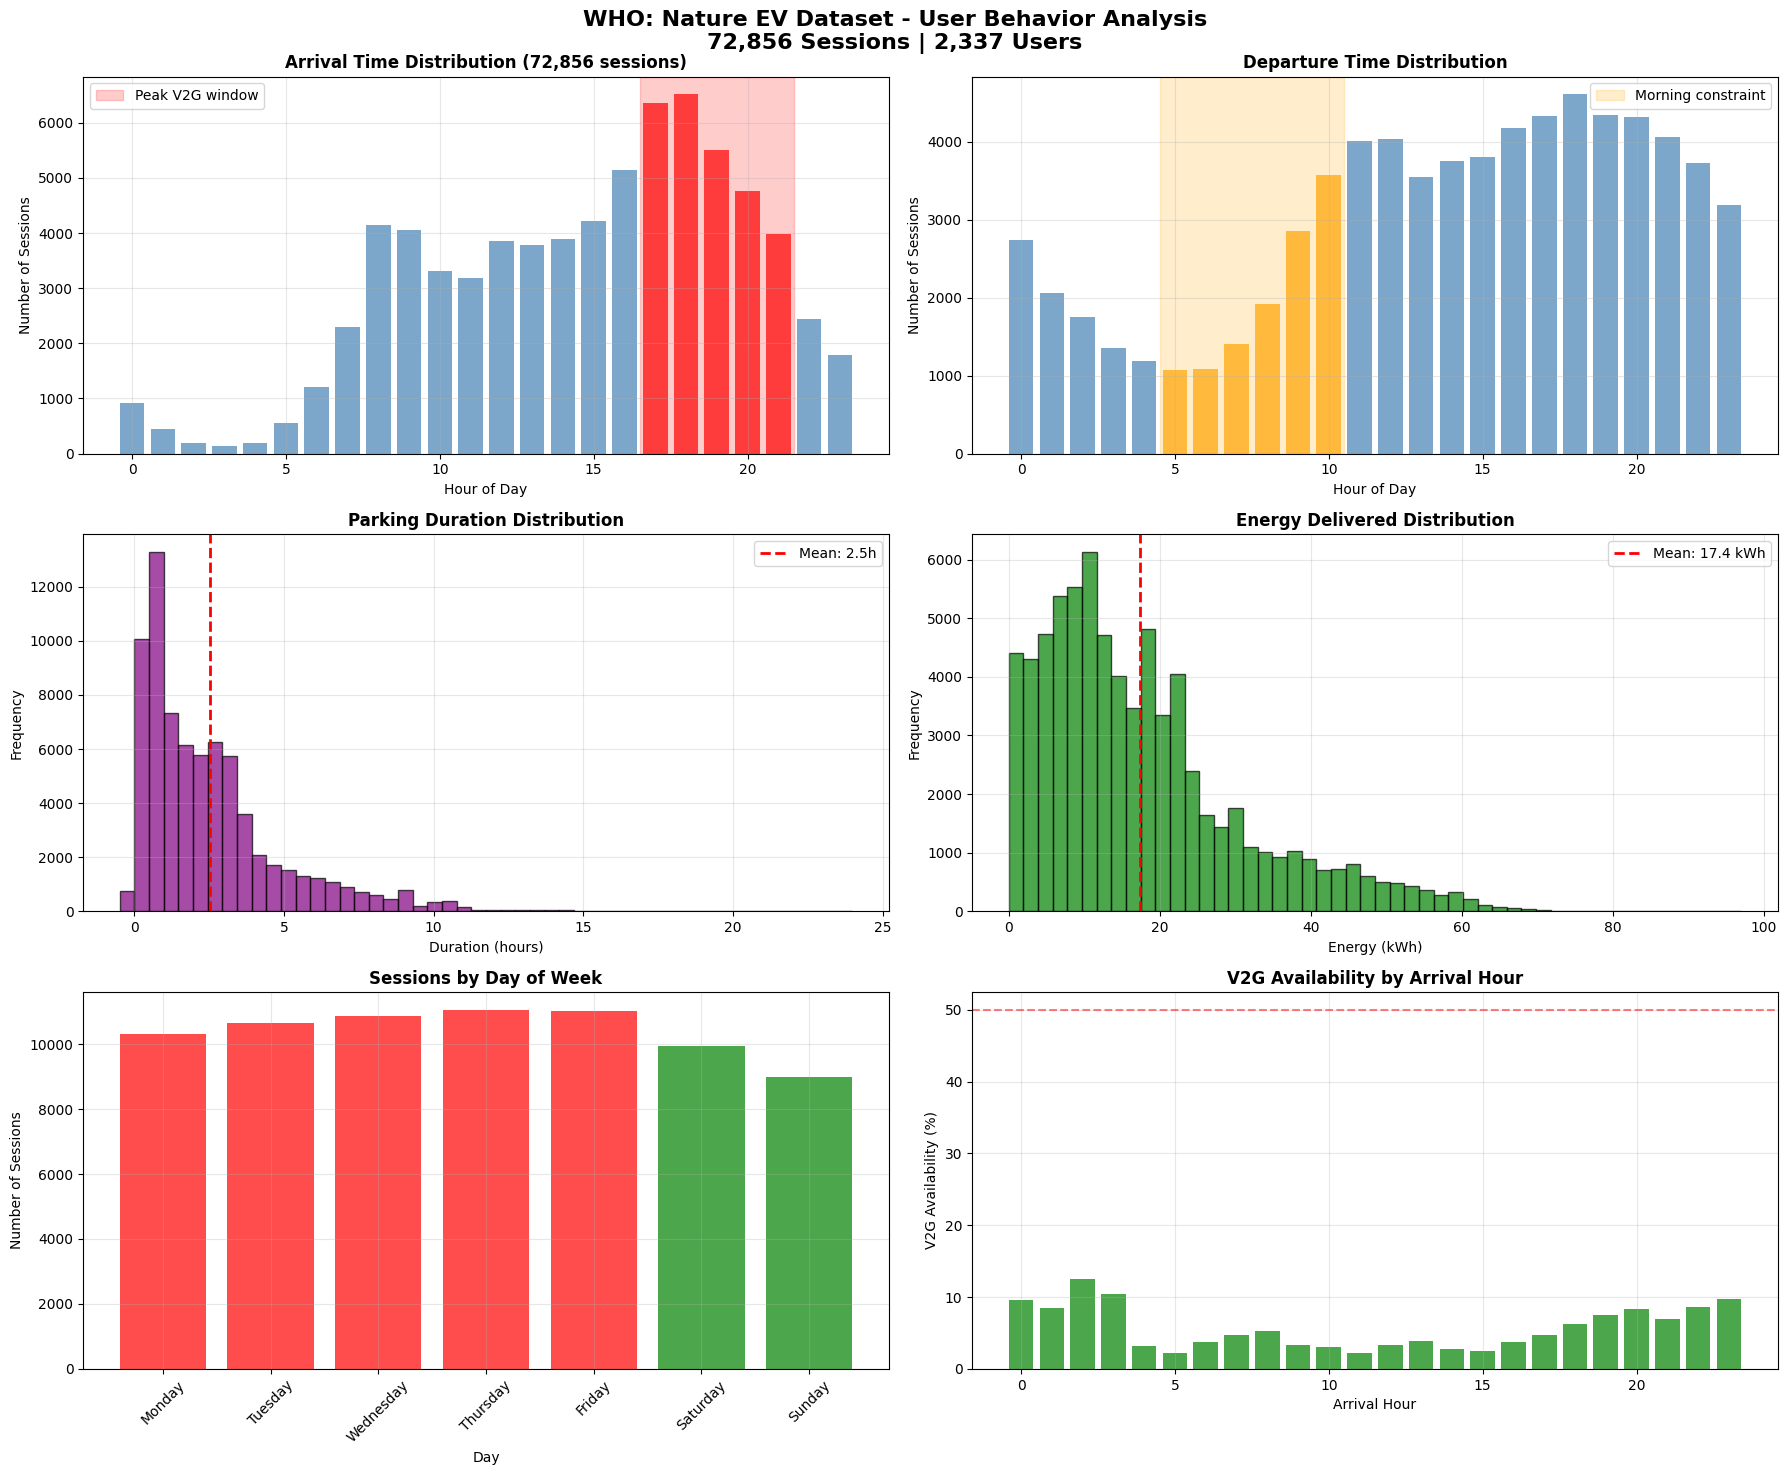

Visualization saved: eda_nature_user_patterns.png

 ANALYSIS COMPLETE!

 KEY FINDINGS:
   Sessions: 72,856
   Users: 2,337
   Peak arrival: 18:00
   V2G available: 5.1%
   Avg idle time: 0.53h

 Files Created:
   • eda_nature_user_patterns.png
   • data/users/processed/user_profiles_nature.csv
   • data/users/processed/nature_dataset_analysis.json

 ready for integration with grid data


In [21]:
def main():
    analyzer = NatureEVAnalyzer('ChargingRecords.csv')
    analysis, df = analyzer.run_complete_analysis()

    if analysis:
        print("\n ready for integration with grid data")
if __name__ == "__main__":
    main()